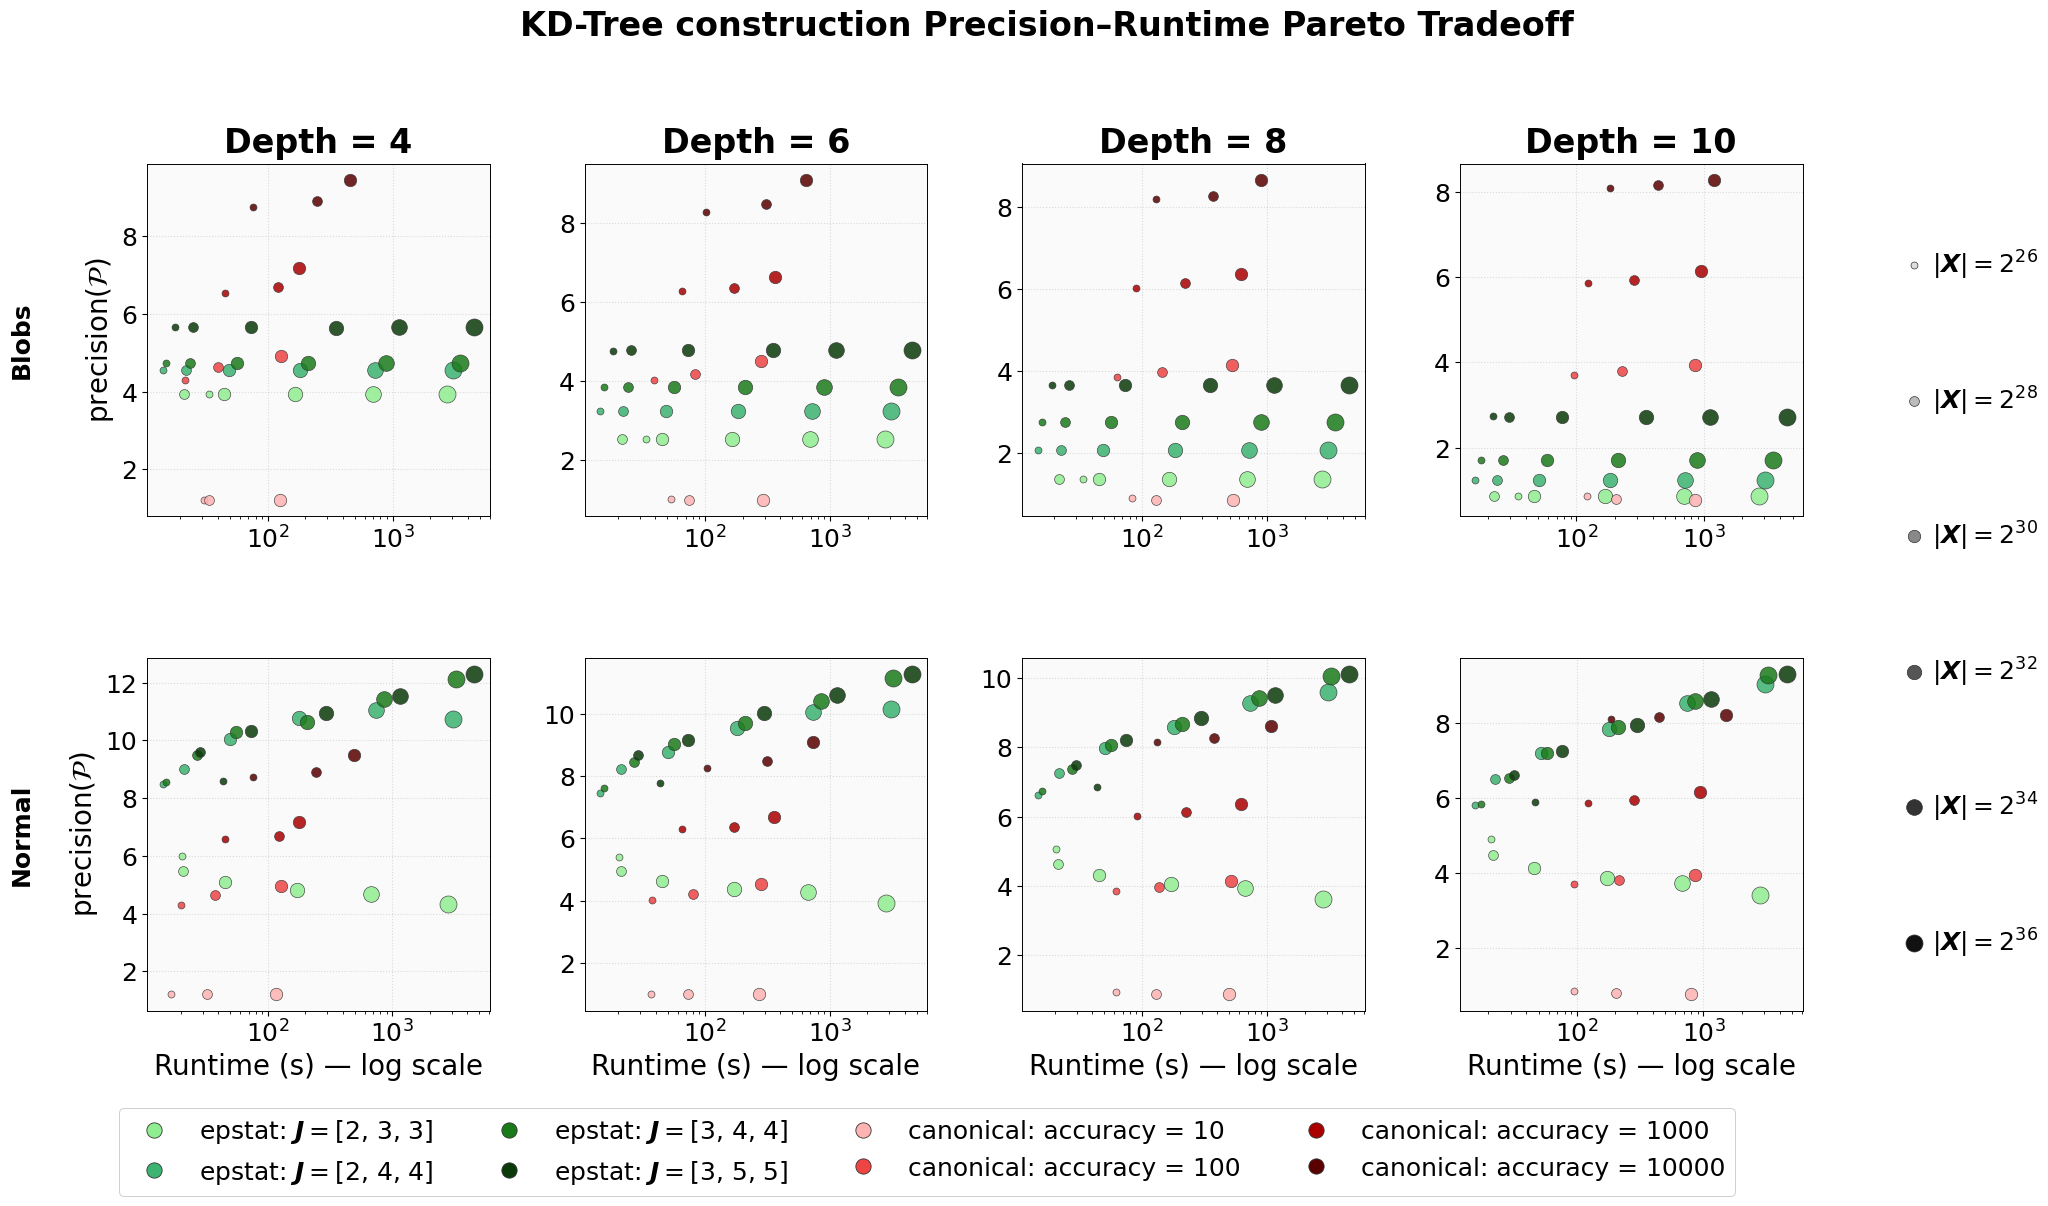

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Global font sizes ──────────────────────────────────────────────────────────
FSIZE = {
    'font':      20,
    'title':     24,
    'label':     20,
    'tick':      18,
    'legend':    18,
    'annot':     18,
    'suptitle':  24,
}
plt.rcParams.update({
    'font.size':        FSIZE['font'],
    'axes.titlesize':   FSIZE['title'],
    'axes.labelsize':   FSIZE['label'],
    'xtick.labelsize':  FSIZE['tick'],
    'ytick.labelsize':  FSIZE['tick'],
    'legend.fontsize':  FSIZE['legend'],
})

# ── Load & combine ─────────────────────────────────────────────────────────────
ep  = pd.read_parquet('epstatKDTree_performance.parquet')
can = pd.read_parquet('canKDTree_performance.parquet')
df  = pd.concat([ep, can], ignore_index=True)

EP_SIZES  = ['2^26', '2^28', '2^30', '2^32', '2^34', '2^36']
CAN_SIZES = ['2^26', '2^28', '2^30']
ALL_SIZES = ['2^26', '2^28', '2^30', '2^32', '2^34', '2^36']
DEPTHS    = [4, 6, 8, 10]
DISTS     = ['blobs', 'normal']

df = df[((df['algorithm'] == 'epstat')    & (df['size'].isin(EP_SIZES))) |
        ((df['algorithm'] == 'canonical') & (df['size'].isin(CAN_SIZES)))].copy()

# ── Colour scheme ──────────────────────────────────────────────────────────────
ep_params  = ['J = [2, 3, 3]', 'J = [2, 4, 4]', 'J = [3, 4, 4]', 'J = [3, 5, 5]']
can_params = ['accuracy = 10', 'accuracy = 100', 'accuracy = 1000', 'accuracy = 10000']

green_shades = ['#90EE90', '#3CB371', '#1A7A1A', '#0A3A0A']
red_shades   = ['#FFB3B3', '#EE4444', '#AA0000', '#5A0000']
grey_shades  = ['#DDDDDD', '#BBBBBB', '#888888', '#555555', '#333333', '#111111']

ep_color  = {p: green_shades[i] for i, p in enumerate(ep_params)}
can_color = {p: red_shades[i]   for i, p in enumerate(can_params)}

def point_color(row):
    return ep_color[row['parameter']] if row['algorithm'] == 'epstat' \
           else can_color[row['parameter']]

df['color'] = df.apply(point_color, axis=1)

size_map = {'2^26': 25, '2^28': 50, '2^30': 80,
            '2^32': 108, '2^34': 128, '2^36': 150}

df['ms'] = df.apply(lambda r: size_map.get(r['size'], 50), axis=1)

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 11))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 5, figure=fig,
                       width_ratios=[1, 1, 1, 1, 0.32],
                       hspace=0.40, wspace=0.32)

axes   = [[fig.add_subplot(gs[r, c]) for c in range(4)] for r in range(2)]
ax_leg = fig.add_subplot(gs[:, 4])
ax_leg.axis('off')

# ── Main panels ────────────────────────────────────────────────────────────────
for row_i, dist in enumerate(DISTS):
    for col_i, depth in enumerate(DEPTHS):
        ax  = axes[row_i][col_i]
        sub = df[(df['distribution'] == dist) & (df['depth'] == depth)].copy()

        for _, r in sub.iterrows():
            ax.scatter(r['runtime'], r['precision'],
                       color=r['color'], s=r['ms'],
                       edgecolors='#333333', linewidths=0.5,
                       zorder=4, alpha=0.85)

        if row_i == 0:
            ax.set_title(f'Depth = {depth}', fontweight='bold', pad=8)
        if row_i == 1:
            ax.set_xlabel('Runtime (s) — log scale')
        if col_i == 0:
            ax.set_ylabel(r'$\mathrm{precision}(\mathcal{P})$')
            ax.annotate(
                'Blobs' if dist == 'blobs' else 'Normal',
                xy=(0, 0.5), xycoords='axes fraction',
                xytext=(-90, 0), textcoords='offset points',
                ha='center', va='center', fontsize=FSIZE['annot'],
                fontweight='bold', rotation=90
            )

        ax.set_xscale('log')
        ax.grid(True, linestyle=':', alpha=0.4, color='#aaaaaa')
        ax.set_facecolor('#FAFAFA')
        for sp in ax.spines.values():
            sp.set_linewidth(0.7)

# ── Right-side size legend ─────────────────────────────────────────────────────
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

n = len(ALL_SIZES)
for i, sz in enumerate(ALL_SIZES):
    y = 0.88 - i * (0.80 / (n - 1))
    ax_leg.scatter([0.15], [y], s=size_map[sz],
                   color=grey_shades[i], edgecolors='#333333',
                   linewidths=0.5, zorder=5,
                   transform=ax_leg.transData)
    ax_leg.text(0.32, y, f'$|\\boldsymbol{{X}}| = 2^{{{sz[2:]}}}$',
                va='center', ha='left', fontsize=FSIZE['legend'],
                transform=ax_leg.transData)

# ── Bottom legend ──────────────────────────────────────────────────────────────
ep_leg = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=green_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11,
           label=f'epstat: {ep_params[i].replace("J = ", "$\\boldsymbol{J} = $")}')
    for i in range(4)
]
can_leg = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=red_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11,
           label=f'canonical: {can_params[i].replace("J = ", "$\\boldsymbol{J} = $")}')
    for i in range(4)
]

leg = fig.legend(
    handles=ep_leg + can_leg,
    loc='lower center', ncol=4,
    fontsize=FSIZE['legend'], framealpha=0.95,
    bbox_to_anchor=(0.45, -0.07),
)
leg.get_frame().set_linewidth(0.7)

fig.suptitle(
    r'KD-Tree construction Precision–Runtime Pareto Tradeoff',
    fontsize=FSIZE['suptitle'], fontweight='bold', y=1.02
)

plt.savefig('figure1.eps',
            format='pdf', dpi=300, bbox_inches='tight')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


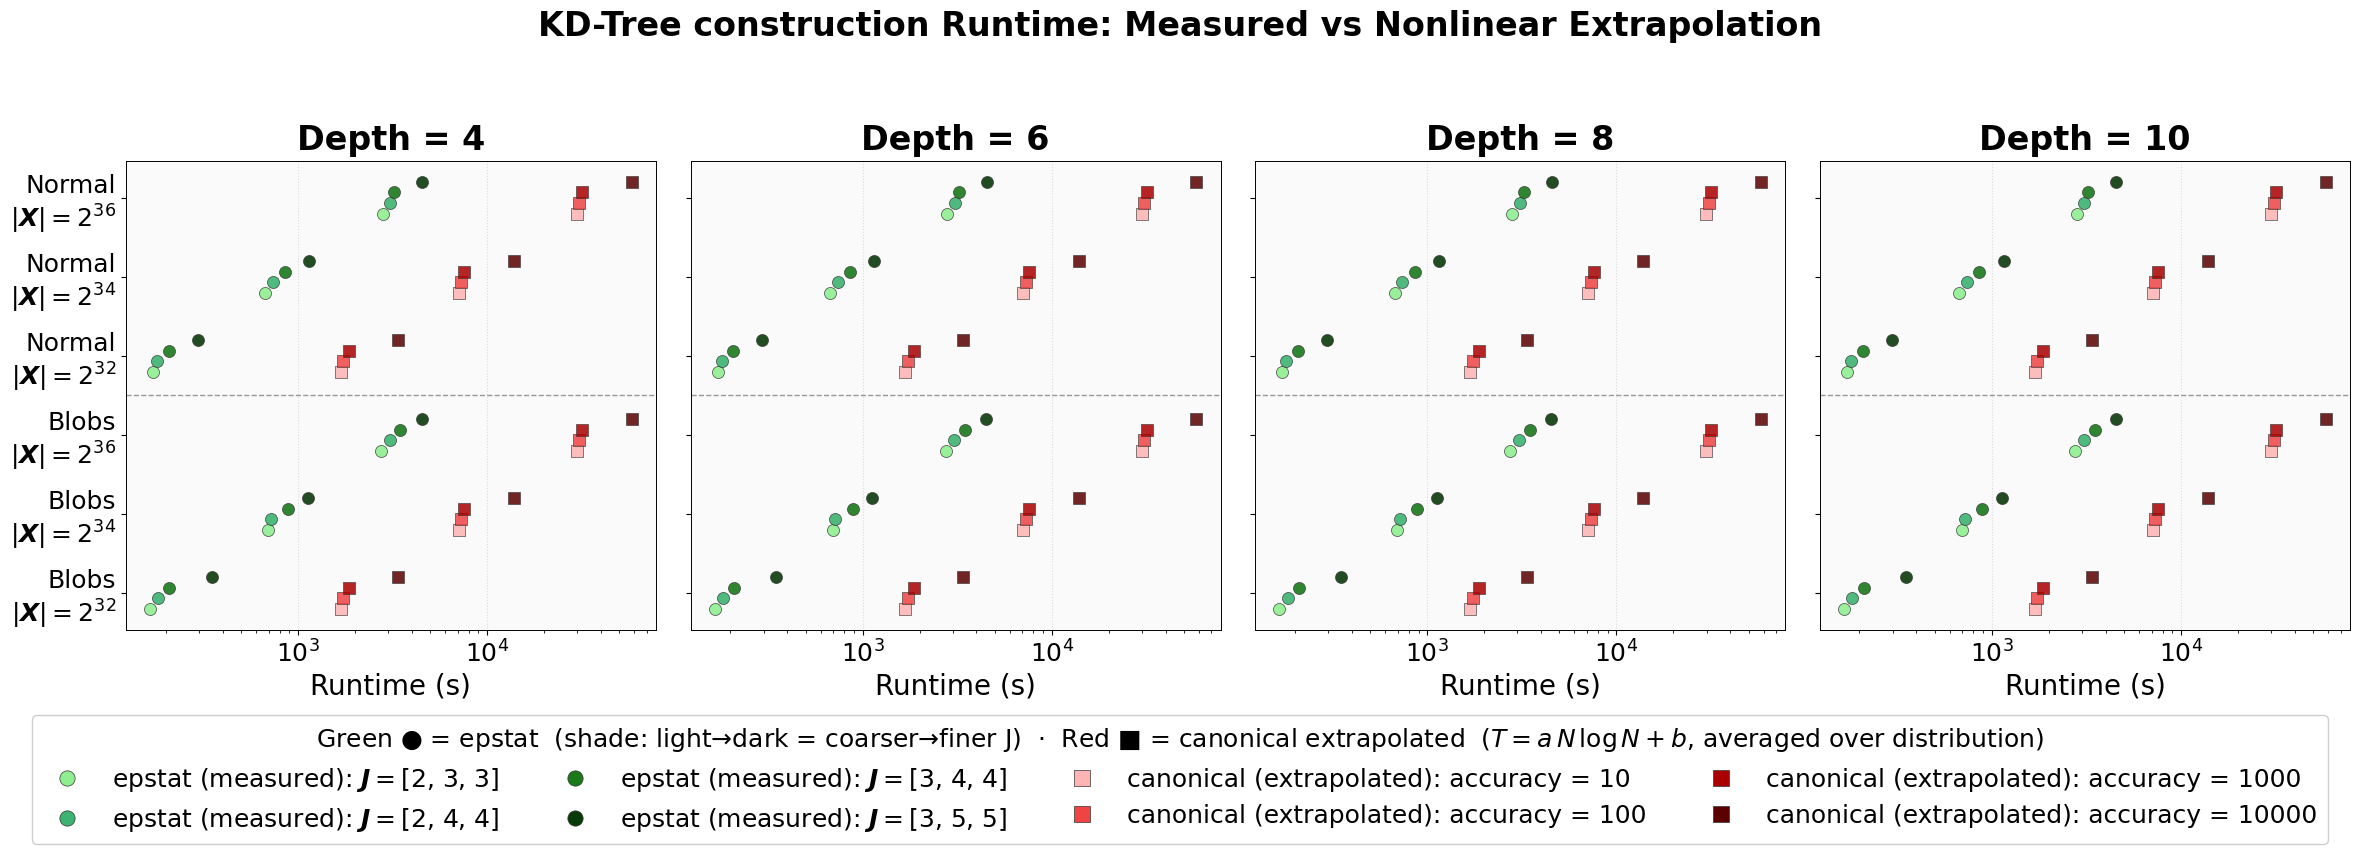

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

# ── Global font sizes (match Plot 1) ──────────────────────────────────────────
FSIZE = {
    'font':      20,
    'title':     24,
    'label':     20,
    'tick':      18,
    'legend':    18,
    'annot':     18,
    'suptitle':  24,
}
plt.rcParams.update({
    'font.size':        FSIZE['font'],
    'axes.titlesize':   FSIZE['title'],
    'axes.labelsize':   FSIZE['label'],
    'xtick.labelsize':  FSIZE['tick'],
    'ytick.labelsize':  FSIZE['tick'],
    'legend.fontsize':  FSIZE['legend'],
})

# ── Load data ──────────────────────────────────────────────────────────────────
ep  = pd.read_parquet('epstatKDTree_performance.parquet')
can = pd.read_parquet('canKDTree_performance.parquet')

ep['N']  = 2.0 ** ep['size'].str[2:].astype(float)
can['N'] = 2.0 ** can['size'].str[2:].astype(float)

LARGE_SIZES = ['2^32', '2^34', '2^36']
DEPTHS      = [4, 6, 8, 10]
DISTS       = ['blobs', 'normal']

ep_params    = ['J = [2, 3, 3]', 'J = [2, 4, 4]', 'J = [3, 4, 4]', 'J = [3, 5, 5]']
can_params   = ['accuracy = 10', 'accuracy = 100', 'accuracy = 1000', 'accuracy = 10000']
green_shades = ['#90EE90', '#3CB371', '#1A7A1A', '#0A3A0A']
red_shades   = ['#FFB3B3', '#EE4444', '#AA0000', '#5A0000']
ep_color     = {p: green_shades[i] for i, p in enumerate(ep_params)}

# ── Model: T = a * N * log(N) + b ─────────────────────────────────────────────
def nlogn_model(N, a, b):
    return a * N * np.log(N) + b

# Fit canonical per param, averaged over distribution
can_fits = {}
for param in can_params:
    sub = (can[can['parameter'] == param]
           .groupby('N', as_index=False)['runtime'].mean()
           .sort_values('N'))
    if len(sub) < 3:
        continue
    N = sub['N'].values
    y = sub['runtime'].values
    try:
        popt, _ = curve_fit(nlogn_model, N, y, p0=[1e-8, 0], maxfev=10000)
        can_fits[param] = popt
    except Exception:
        pass

# ── Y-axis: 6 categories = dist x size ────────────────────────────────────────
y_cats   = [(dist, sz) for dist in DISTS for sz in LARGE_SIZES]
y_labels = [f"{'Blobs' if d=='blobs' else 'Normal'}\n$|\\boldsymbol{{X}}| = 2^{{{sz[2:]}}}$"
            for d, sz in y_cats]
n_cats   = len(y_cats)

ep_jitter  = np.linspace(-0.20, 0.20, 4)
can_jitter = np.linspace(-0.20, 0.20, 4)

# ── 1×4 Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 7), sharey=True)
fig.patch.set_facecolor('white')

for col_i, depth in enumerate(DEPTHS):
    ax = axes[col_i]

    for cat_i, (dist, sz) in enumerate(y_cats):
        N_val = 2.0 ** float(sz[2:])
        yc    = cat_i

        # Canonical extrapolated: 4 points per row, jittered
        for p_i, param in enumerate(can_params):
            if param not in can_fits:
                continue
            rt_can = nlogn_model(N_val, *can_fits[param])
            ax.scatter(rt_can, yc + can_jitter[p_i],
                       marker='s', color=red_shades[p_i], s=70,
                       edgecolors='#333333', linewidths=0.5,
                       zorder=4, alpha=0.85)

        # epstat measured: 4 param points jittered
        ep_sub = ep[(ep['distribution'] == dist) &
                    (ep['depth'] == depth) &
                    (ep['size'] == sz)]
        for p_i, param in enumerate(ep_params):
            row = ep_sub[ep_sub['parameter'] == param]
            if row.empty:
                continue
            rt = row['runtime'].values[0]
            ax.scatter(rt, yc + ep_jitter[p_i],
                       marker='o', color=ep_color[param], s=75,
                       edgecolors='#333333', linewidths=0.5,
                       zorder=5, alpha=0.90)

    # Separator between blobs and normal
    ax.axhline(y=2.5, color='#999999', linewidth=1.0, linestyle='--', zorder=1)

    ax.set_xscale('log')
    ax.set_xlabel('Runtime (s)')
    ax.set_title(f'Depth = {depth}', fontweight='bold', pad=8)
    ax.set_yticks(range(n_cats))
    if col_i == 0:
        ax.set_yticklabels(y_labels)
    ax.invert_yaxis()
    ax.grid(True, axis='x', linestyle=':', alpha=0.4, color='#aaaaaa')
    ax.set_facecolor('#FAFAFA')
    for sp in ax.spines.values():
        sp.set_linewidth(0.7)

# ── Legend ─────────────────────────────────────────────────────────────────────
ep_leg = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=green_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.5, markersize=11,
           label=f'epstat (measured): {ep_params[i].replace("J = ", "$\\boldsymbol{J} = $")}')
    for i in range(4)
]
can_leg = [
    Line2D([0],[0], marker='s', color='w',
           markerfacecolor=red_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.5, markersize=11,
           label=f'canonical (extrapolated): {can_params[i].replace("J = ", "$\\boldsymbol{J} = $")}')
    for i in range(4)
]

fig.legend(
    handles=ep_leg + can_leg,
    loc='lower center', ncol=4,
    fontsize=FSIZE['legend'], framealpha=0.95,
    bbox_to_anchor=(0.5, -0.18),
    title=r'Green ● = epstat  (shade: light→dark = coarser→finer J)  ·  Red ■ = canonical extrapolated  ($T = a\,N\,\log N + b$, averaged over distribution)',
    title_fontsize=FSIZE['legend'],
)

plt.subplots_adjust(bottom=0.18)

fig.suptitle(
    r'KD-Tree construction Runtime: Measured vs Nonlinear Extrapolation',
    fontsize=FSIZE['suptitle'], fontweight='bold', y=1.03
)

plt.tight_layout()
plt.savefig('figure2.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


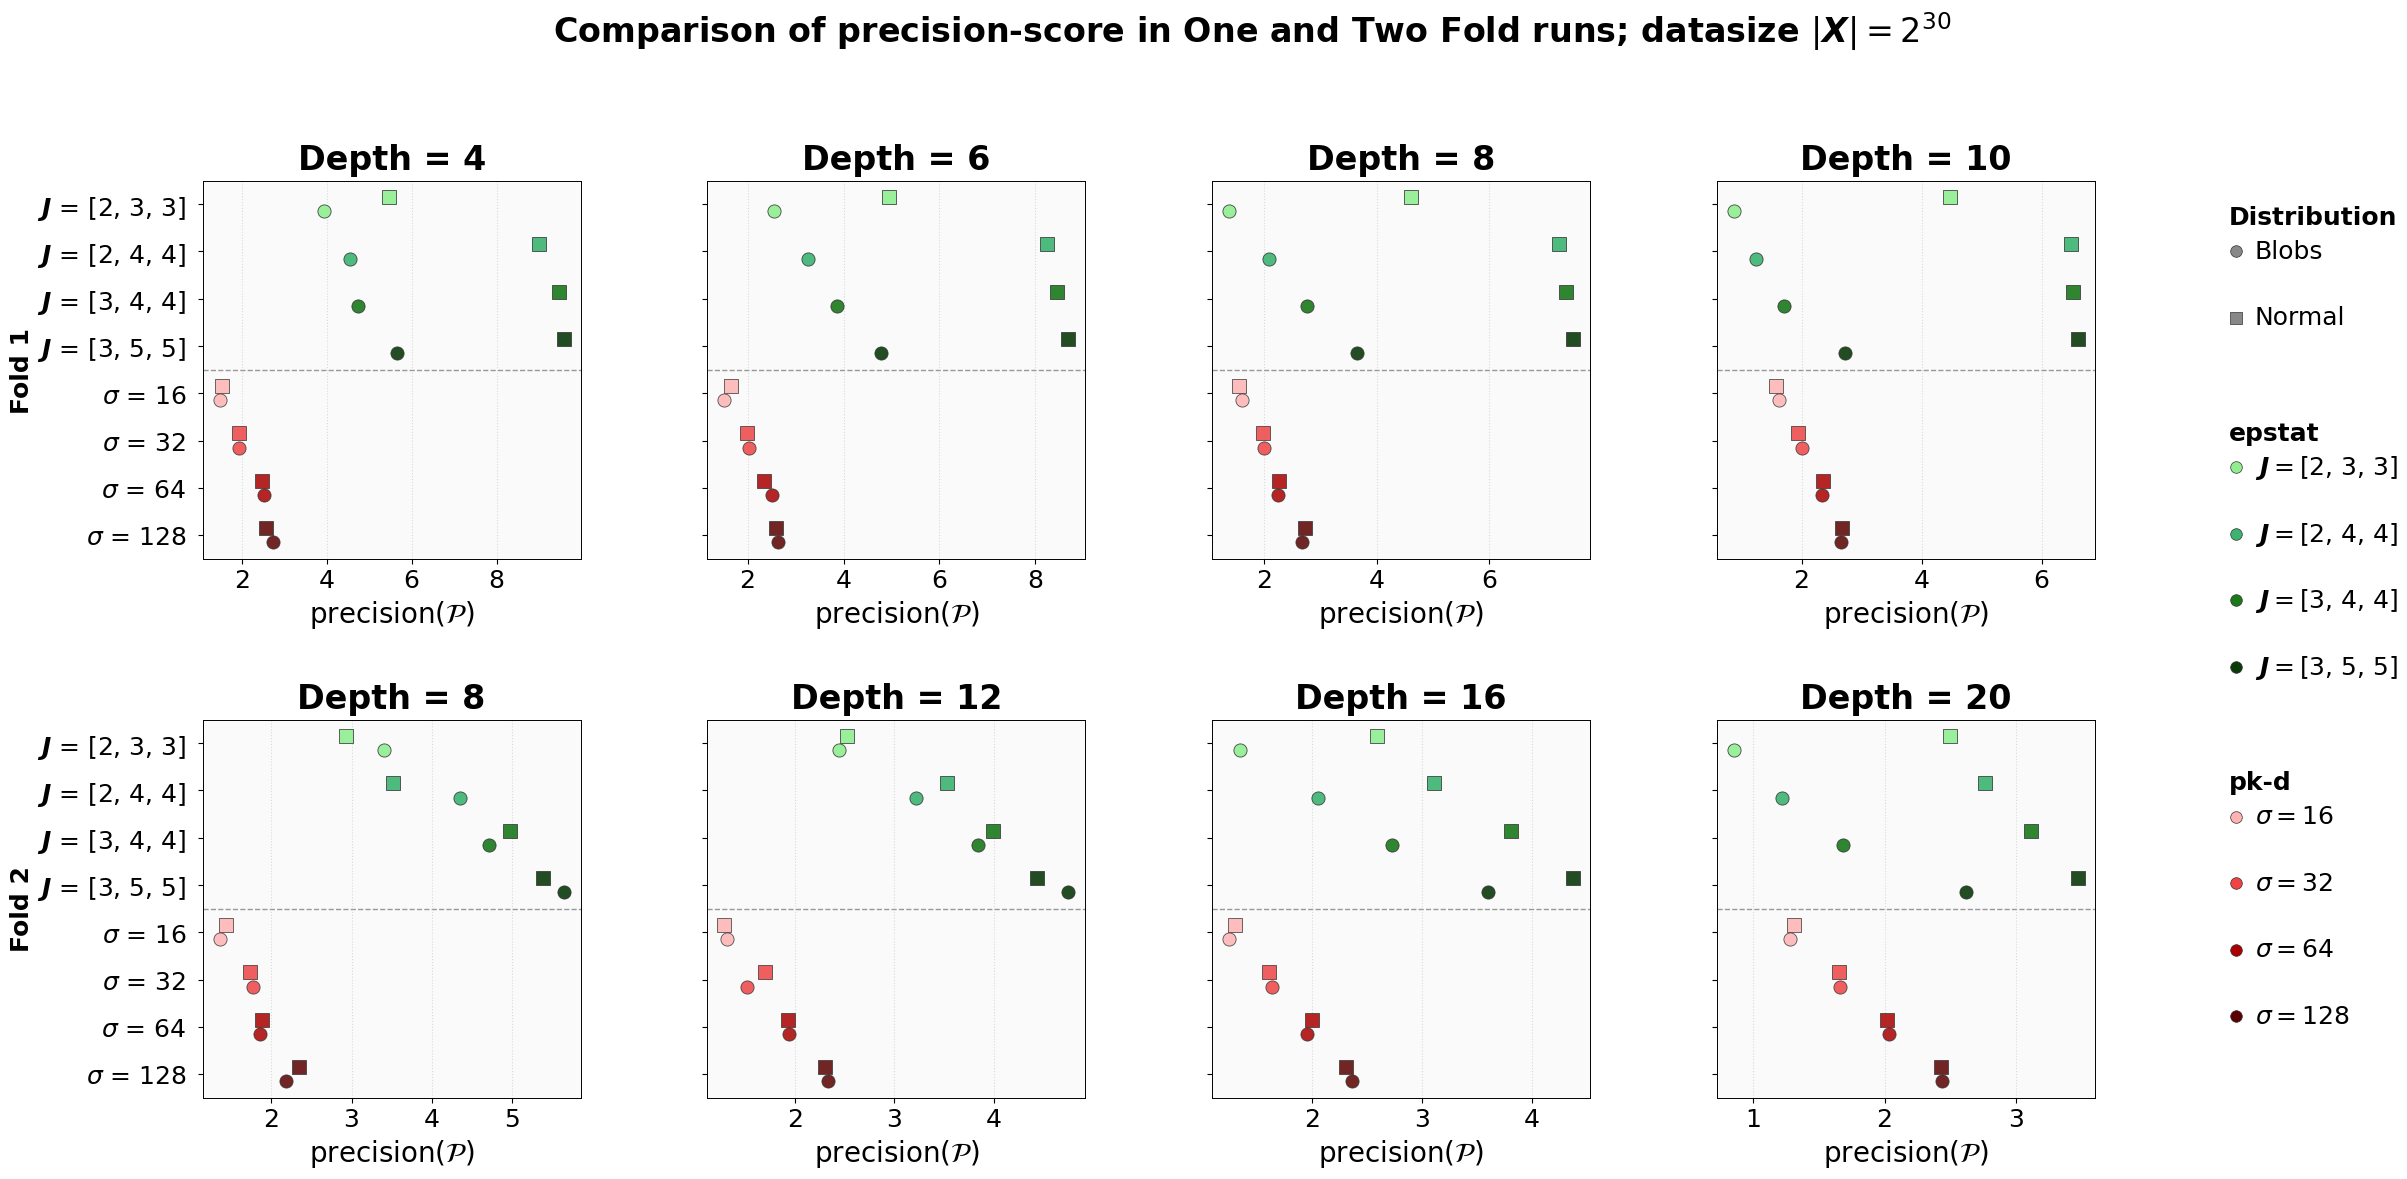

In [3]:
# ── Plot 3: Precision vs Parameter (epstat & pKD-Tree) ─────────────────────────
# Row 1 (fold 1): depths 4, 6, 8, 10
# Row 2 (fold 2): depths 8, 12, 16, 20
# x-axis : precision  |  y-axis : parameter
# Circles (○) = blobs distribution, Squares (□) = normal distribution
# Green shades = epstat params, Red shades = pkd params
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

FSIZE = {
    'font':      20,
    'title':     24,
    'label':     20,
    'tick':      18,
    'legend':    18,
    'annot':     18,
    'suptitle':  24,
}
plt.rcParams.update({
    'font.size':        FSIZE['font'],
    'axes.titlesize':   FSIZE['title'],
    'axes.labelsize':   FSIZE['label'],
    'xtick.labelsize':  FSIZE['tick'],
    'ytick.labelsize':  FSIZE['tick'],
    'legend.fontsize':  FSIZE['legend'],
})

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_parquet('pKDTree_performance.parquet')

# ── Parameters and colour scheme ──────────────────────────────────────────────
ep_params  = ['J = [2, 3, 3]', 'J = [2, 4, 4]', 'J = [3, 4, 4]', 'J = [3, 5, 5]']
pkd_params = ['sigma = 16',    'sigma = 32',    'sigma = 64',    'sigma = 128']

green_shades = ['#90EE90', '#3CB371', '#1A7A1A', '#0A3A0A']
red_shades   = ['#FFB3B3', '#EE4444', '#AA0000', '#5A0000']

ep_color  = {p: green_shades[i] for i, p in enumerate(ep_params)}
pkd_color = {p: red_shades[i]   for i, p in enumerate(pkd_params)}

# Y-axis: pkd params (bottom block) then epstat params (top block)
# We order epstat on top half, pkd on bottom half
all_params  = ep_params + pkd_params          # 8 entries total
y_pos       = {p: i for i, p in enumerate(all_params)}
all_params_display = [p.replace("J = ", "$\\boldsymbol{J}$ = ") for p in ep_params] + [p.replace("sigma = ", "$\\sigma$ = ") for p in pkd_params]

# Fold layouts
FOLD_DEPTHS = {1: [4, 6, 8, 10], 2: [8, 12, 16, 20]}
DISTS       = ['blobs', 'normal']

# Jitter within each y-tick: blobs slightly up, normal slightly down
JITTER = {'blobs': +0.15, 'normal': -0.15}
MARKER = {'blobs': 'o', 'normal': 's'}

# ── Layout: 2 rows × 4 panels + 1 legend column ──────────────────────────────
fig = plt.figure(figsize=(28, 12))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 5, figure=fig,
                       width_ratios=[1, 1, 1, 1, 0.40],
                       hspace=0.40, wspace=0.38)

axes   = [[fig.add_subplot(gs[r, c]) for c in range(4)] for r in range(2)]
ax_leg = fig.add_subplot(gs[:, 4])
ax_leg.axis('off')

n_params = len(all_params)

for row_i, fold in enumerate([1, 2]):
    depths = FOLD_DEPTHS[fold]
    fold_sub = df[df['fold'] == fold].copy()

    for col_i, depth in enumerate(depths):
        ax   = axes[row_i][col_i]
        sub  = fold_sub[fold_sub['depth'] == depth].copy()

        for dist in DISTS:
            dsub = sub[sub['distribution'] == dist]

            # epstat points
            for param in ep_params:
                row = dsub[(dsub['algorithm'] == 'epstat') & (dsub['parameter'] == param)]
                if row.empty:
                    continue
                acc = row['precision'].values[0]
                yv  = y_pos[param] + JITTER[dist]
                ax.scatter(acc, yv,
                           marker=MARKER[dist],
                           color=ep_color[param], s=90,
                           edgecolors='#333333', linewidths=0.6,
                           zorder=5, alpha=0.90)

            # pkd points
            for param in pkd_params:
                row = dsub[(dsub['algorithm'] == 'pkd') & (dsub['parameter'] == param)]
                if row.empty:
                    continue
                acc = row['precision'].values[0]
                yv  = y_pos[param] + JITTER[dist]
                ax.scatter(acc, yv,
                           marker=MARKER[dist],
                           color=pkd_color[param], s=90,
                           edgecolors='#333333', linewidths=0.6,
                           zorder=4, alpha=0.85)

        # Separator between epstat (top) and pkd (bottom) param blocks
        ax.axhline(y=3.5, color='#999999', linewidth=1.0, linestyle='--', zorder=1)

        # Axes formatting
        ax.set_title(f'Depth = {depth}', fontweight='bold', pad=8)
        ax.set_yticks(range(n_params))

        if col_i == 0:
            ax.set_yticklabels(all_params_display)
            ax.tick_params(axis='y', pad=8)
            ax.annotate(
                f'Fold {fold}',
                xy=(0, 0.5), xycoords='axes fraction',
                xytext=(-130, 0), textcoords='offset points',
                ha='center', va='center', fontsize=FSIZE['annot'],
                fontweight='bold', rotation=90
            )
        else:
            ax.set_yticklabels([])

        ax.set_ylim(-0.5, n_params - 0.5)
        ax.set_box_aspect(1)
        ax.invert_yaxis()
        ax.set_xlabel('precision($\\mathcal{P}$)')
        ax.grid(True, axis='x', linestyle=':', alpha=0.4, color='#aaaaaa')
        ax.set_facecolor('#FAFAFA')
        for sp in ax.spines.values():
            sp.set_linewidth(0.7)

# ── Right-side legend ─────────────────────────────────────────────────────────
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)

# Distribution shape legend
shape_handles = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='#888888', markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11, label='Blobs'),
    Line2D([0],[0], marker='s', color='w',
           markerfacecolor='#888888', markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11, label='Normal'),
]
ep_handles = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=green_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11, label=ep_params[i].replace("J = ", "$\\boldsymbol{J} = $"))
    for i in range(4)
]
pkd_handles = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=red_shades[i], markeredgecolor='#333333',
           markeredgewidth=0.6, markersize=11, label=pkd_params[i].replace("sigma = ", "$\\sigma = $"))
    for i in range(4)
]

# Draw legend sections manually in the legend axes
y_cursor = 0.97

def draw_section(ax_leg, title, handles, y_start, dy=0.075):
    ax_leg.text(0.05, y_start, title, fontsize=FSIZE['legend'], fontweight='bold',
                va='top', transform=ax_leg.transAxes)
    y_start -= 0.05
    for h in handles:
        fc = h.get_markerfacecolor()
        mk = h.get_marker()
        ax_leg.scatter([0.10], [y_start], s=70,
                       marker=mk, color=fc,
                       edgecolors='#333333', linewidths=0.5,
                       transform=ax_leg.transAxes, clip_on=False)
        ax_leg.text(0.22, y_start, h.get_label(), fontsize=FSIZE['legend'],
                    va='center', transform=ax_leg.transAxes)
        y_start -= dy
    return y_start

y_cursor = draw_section(ax_leg, 'Distribution', shape_handles, y_cursor, dy=0.072)
y_cursor -= 0.04
y_cursor = draw_section(ax_leg, 'epstat', ep_handles,   y_cursor, dy=0.072)
y_cursor -= 0.04
y_cursor = draw_section(ax_leg, 'pk-d',   pkd_handles,  y_cursor, dy=0.072)

fig.suptitle(
    f'Comparison of precision-score in One and Two Fold runs; datasize $|\\boldsymbol{{X}}| = 2^{{{30}}}$',
    fontsize=FSIZE['suptitle'], fontweight='bold', y=1.02
)

plt.savefig('figure3.eps',
            format='eps', dpi=300, bbox_inches='tight')
plt.show()
